# Chapter 3: Biomedical Data Ecosystems

## Hands-On Jupyter Notebook

This notebook implements practical workflows for integrating biomedical repositories into agentic AI pipelines for cancer research.

**Time to Complete**: 1-2 hours

**What You Will Build**
- A lightweight multi-source data ingestion workflow
- A harmonized evidence table with provenance
- Retrieval-ready summaries for downstream agent tools

---

## Section 1: Setup and Imports

This section configures the notebook, imports required libraries, and defines utilities used across exercises.

In [1]:
# Standard library imports
import json
import os
from datetime import datetime, timezone
from typing import Any, Dict, List, Optional
import warnings

warnings.filterwarnings('ignore')

# Data processing
import numpy as np
import pandas as pd
import requests

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

# Configuration
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

def now_utc_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

print('Environment configured successfully.')
print(f'Notebook timestamp (UTC): {now_utc_iso()}')

Environment configured successfully.
Notebook timestamp (UTC): 2026-05-21T13:39:36.533051+00:00


## Section 2: Data Acquisition (API + Local Fallback)

We query the cBioPortal public API for studies and also define a pediatric portal catalog for age-aware ecosystem mapping. If network access is unavailable, the cell uses a local fallback dataset so the notebook remains runnable.

In [9]:
CBIO_STUDIES_URL = 'https://www.cbioportal.org/api/studies'

def fetch_cbio_studies(limit: int = 40, timeout: int = 20) -> pd.DataFrame:
    headers = {'Accept': 'application/json'}
    resp = requests.get(CBIO_STUDIES_URL, headers=headers, timeout=timeout)
    resp.raise_for_status()
    payload = resp.json()
    if not isinstance(payload, list):
        raise ValueError('Unexpected cBioPortal response format.')
    df = pd.DataFrame(payload)
    return df.head(limit).copy()

fallback_studies = [
    {'studyId': 'brca_tcga_pan_can_atlas_2018', 'name': 'Breast Invasive Carcinoma (TCGA, PanCancer Atlas)'},
    {'studyId': 'luad_tcga_pan_can_atlas_2018', 'name': 'Lung Adenocarcinoma (TCGA, PanCancer Atlas)'},
    {'studyId': 'target_all_p3', 'name': 'TARGET Pan-Cancer Pediatric Cohort'},
    {'studyId': 'pbta_open_2024', 'name': 'OpenPBTA Pediatric Brain Tumor Atlas'},
]

pediatric_portals = pd.DataFrame([
    {'resource': 'TARGET', 'focus': 'Pediatric genomics cohorts', 'access': 'Mixed public/controlled'},
    {'resource': 'St. Jude Cloud', 'focus': 'Childhood cancer genomics + workflows', 'access': 'Account + governance dependent'},
    {'resource': 'Kids First DRC', 'focus': 'Childhood cancer and developmental cohorts', 'access': 'Mixed public/controlled'},
    {'resource': 'PedcBioPortal', 'focus': 'Pediatric cBioPortal studies and exploration', 'access': 'Public portal + study-level variation'},
    {'resource': 'OpenPBTA/CBTN', 'focus': 'Pediatric brain tumor collaborative analyses', 'access': 'Public outputs + controlled components'},
])

source_status = {'source': None, 'retrieved_at_utc': now_utc_iso(), 'record_count': 0}

try:
    studies_df = fetch_cbio_studies(limit=50)
    source_status['source'] = 'cBioPortal API'
except Exception as exc:
    studies_df = pd.DataFrame(fallback_studies)
    source_status['source'] = f'local fallback ({type(exc).__name__})'

source_status['record_count'] = int(len(studies_df))

display(pd.DataFrame([source_status]))
display(studies_df.head(10))
display(pediatric_portals)

,source,retrieved_at_utc,record_count
0,cBioPortal API,2026-05-21T13:47:04.161775+00:00,50


,name,description,publicStudy,groups,status,importDate,allSampleCount,readPermission,resourceCounts,studyId,cancerTypeId,referenceGenome,pmid,citation
0,"Breast Cancer (CPTAC GDC, 2025)",CPTAC Breast Cancer. Source data from <A HREF=...,True,PUBLIC,0,2026-01-16 15:45:46,1,True,[],breast_cptac_gdc,breast,hg38,NaN,NaN
1,"Glioma (MSK, Clin Cancer Res 2019)",Targeted sequencing on MSK-IMPACT and FMI Pane...,True,PUBLIC,0,2026-01-07 13:10:52,1,True,[],glioma_mskcc_2019,difg,hg19,31263031,Jonsson et al. Clin Cancer Res 2019
2,"Osteosarcoma (TARGET GDC, 2025)",TARGET Osteosarcoma. Source data from <A HREF=...,True,PUBLIC,0,2026-01-14 12:41:40,1,True,[],os_target_gdc,os,hg38,NaN,NaN
3,"Prostate Cancer MDA PCa PDX (MD Anderson, Clin...",Targeted sequencing and whole-genome sequencin...,True,,0,2026-01-13 10:27:05,1,True,[],prad_msk_mdanderson_2023,prostate,hg19,38488813,Anselmino et al. Clin Cancer Res 2024
4,"Uterine Endometrioid Carcinoma (CPTAC GDC, 2025)",CPTAC Uterine Endometrioid Carcinoma. Source d...,True,PUBLIC,0,2026-01-14 11:20:38,1,True,[],uec_cptac_gdc,uec,hg38,NaN,NaN
5,"Urothelial Carcinoma (Cornell/Trento, Nat Gen ...",Whole-exome sequencing of 72 tumor samples (wi...,True,PUBLIC,0,2026-01-05 13:46:49,1,True,[],blca_cornell_2016,blca,hg19,27749842,"Faltas and Prandi, Nature Genetics 2016"
6,"Basal Cell Carcinoma (UNIGE, Nat Genet 2016)",Whole-exome sequencing of 126 basal cell carci...,True,PUBLIC,0,2026-01-05 13:44:39,1,True,[],bcc_unige_2016,bcc,hg19,26950094,Bonilla et al. Nat Genet 2016
7,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",TCGA Colorectal Adenocarcinoma. Source data fr...,True,PUBLIC,0,2026-01-06 23:41:01,1,True,[],coadread_tcga,coadread,hg19,NaN,NaN
8,"Lung Adenocarcinoma (CPTAC GDC, 2025)",CPTAC Lung Adenocarcinoma. Source data from <A...,True,PUBLIC,0,2026-01-14 10:47:44,1,True,[],luad_cptac_gdc,luad,hg38,NaN,NaN
9,"Breast Invasive Carcinoma (Broad, Nature 2012)",Whole-exome sequencing of 103 breast cancer tu...,True,PUBLIC,0,2026-01-05 16:15:10,1,True,[],brca_broad,brca,hg19,22722202,Banerji et al. Nature 2012


,resource,focus,access
0,TARGET,Pediatric genomics cohorts,Mixed public/controlled
1,St. Jude Cloud,Childhood cancer genomics + workflows,Account + governance dependent
2,Kids First DRC,Childhood cancer and developmental cohorts,Mixed public/controlled
3,PedcBioPortal,Pediatric cBioPortal studies and exploration,Public portal + study-level variation
4,OpenPBTA/CBTN,Pediatric brain tumor collaborative analyses,Public outputs + controlled components


## Section 3: Harmonization and Provenance

We normalize study metadata, attach provenance fields, and add an age-context flag so pediatric and adult cohorts can be filtered explicitly in downstream agent pipelines.

In [10]:
def normalize_study_table(df: pd.DataFrame, source_name: str) -> pd.DataFrame:
    out = df.copy()

    # Normalize expected fields.
    if 'studyId' not in out.columns:
        out['studyId'] = [f'unknown_{i}' for i in range(len(out))]
    if 'name' not in out.columns:
        out['name'] = out['studyId']

    out['study_id'] = out['studyId'].astype(str)
    out['study_name'] = out['name'].astype(str)
    out['tumor_hint'] = out['study_name'].str.extract(r'^(.*?)\s*\(').fillna(out['study_name'])
    out['source'] = source_name
    out['retrieved_at_utc'] = now_utc_iso()
    out['record_version'] = 'v1'

    pediatric_markers = ['pediatric', 'child', 'children', 'target', 'pbta', 'kids first', 'st. jude']
    marker_pattern = '|'.join(pediatric_markers)
    text_blob = (out['study_id'].str.lower() + ' ' + out['study_name'].str.lower())
    out['age_context'] = np.where(text_blob.str.contains(marker_pattern, regex=True), 'pediatric_or_aya', 'adult_or_unspecified')

    keep_cols = [
        'study_id',
        'study_name',
        'tumor_hint',
        'age_context',
        'source',
        'retrieved_at_utc',
        'record_version',
    ]
    return out[keep_cols]

harmonized_studies = normalize_study_table(studies_df, source_status['source'])
display(harmonized_studies.head(10))
display(harmonized_studies['age_context'].value_counts().rename_axis('age_context').to_frame('count'))
print(f'Harmonized records: {len(harmonized_studies)}')

,study_id,study_name,tumor_hint,age_context,source,retrieved_at_utc,record_version
0,breast_cptac_gdc,"Breast Cancer (CPTAC GDC, 2025)",Breast Cancer,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
1,glioma_mskcc_2019,"Glioma (MSK, Clin Cancer Res 2019)",Glioma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
2,os_target_gdc,"Osteosarcoma (TARGET GDC, 2025)",Osteosarcoma,pediatric_or_aya,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
3,prad_msk_mdanderson_2023,"Prostate Cancer MDA PCa PDX (MD Anderson, Clin...",Prostate Cancer MDA PCa PDX,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
4,uec_cptac_gdc,"Uterine Endometrioid Carcinoma (CPTAC GDC, 2025)",Uterine Endometrioid Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
5,blca_cornell_2016,"Urothelial Carcinoma (Cornell/Trento, Nat Gen ...",Urothelial Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
6,bcc_unige_2016,"Basal Cell Carcinoma (UNIGE, Nat Genet 2016)",Basal Cell Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
7,coadread_tcga,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",Colorectal Adenocarcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
8,luad_cptac_gdc,"Lung Adenocarcinoma (CPTAC GDC, 2025)",Lung Adenocarcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1
9,brca_broad,"Breast Invasive Carcinoma (Broad, Nature 2012)",Breast Invasive Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1


,count
age_context,
adult_or_unspecified,49
pediatric_or_aya,1


Harmonized records: 50


## Section 4: Ecosystem Coverage Visualization

This visualization creates a high-level profile of source records and inferred tumor context terms.

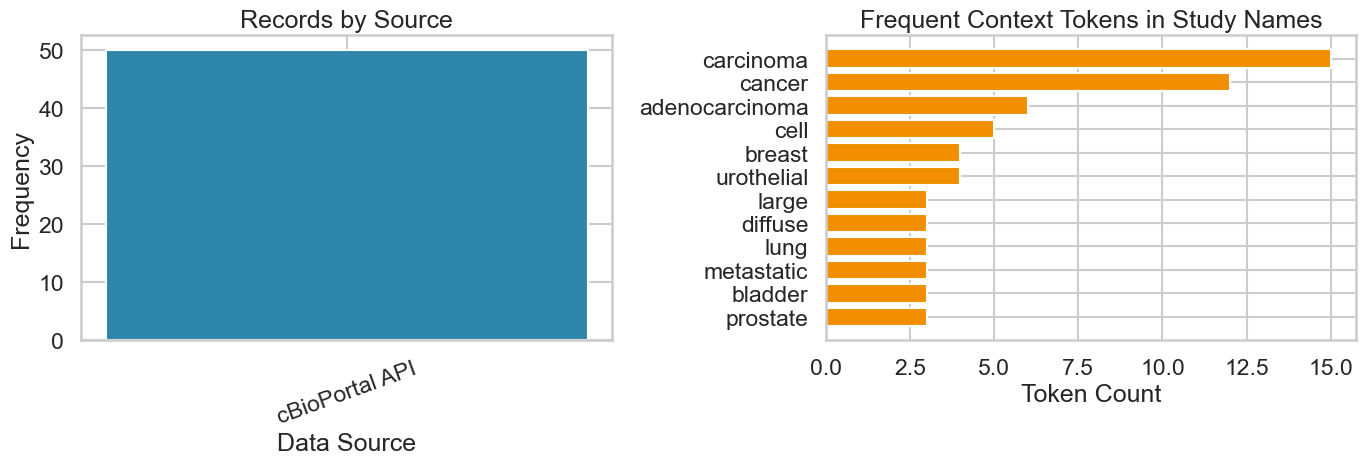

In [4]:
token_series = (
    harmonized_studies['tumor_hint']
    .str.lower()
    .str.replace('[^a-z0-9 ]', ' ', regex=True)
    .str.split()
    .explode()
    .dropna()
)
token_series = token_series[token_series.str.len() >= 4]
top_tokens = token_series.value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: record count by source
source_counts = harmonized_studies['source'].value_counts()
axes[0].bar(source_counts.index, source_counts.values, color=['#2E86AB'])
axes[0].set_xlabel('Data Source')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Records by Source')
axes[0].tick_params(axis='x', rotation=20)

# Plot 2: top extracted tumor/context terms
axes[1].barh(top_tokens.index[::-1], top_tokens.values[::-1], color='#F18F01')
axes[1].set_xlabel('Token Count')
axes[1].set_title('Frequent Context Tokens in Study Names')

plt.tight_layout()
plt.show()

## Section 5: Exercises

### Exercise 1: Multi-Source Evidence Table

Build a compact evidence table that joins study metadata with interpretation fields, pediatric resource context, and provenance columns.

In [11]:
# Exercise 1 solution template
interpretation_rows = [
    {'gene': 'TP53', 'evidence_source': 'CIViC', 'evidence_level': 'B', 'context': 'cross-age interpretation'},
    {'gene': 'EGFR', 'evidence_source': 'OncoKB', 'evidence_level': 'A', 'context': 'adult-focused actionability'},
    {'gene': 'PIK3CA', 'evidence_source': 'Kids First DRC', 'evidence_level': 'C', 'context': 'pediatric cohort signal'},
    {'gene': 'H3F3A', 'evidence_source': 'OpenPBTA/CBTN', 'evidence_level': 'B', 'context': 'pediatric CNS context'},
]
interpretation_df = pd.DataFrame(interpretation_rows)

evidence_table = harmonized_studies.head(12).copy()
evidence_table['gene'] = np.random.choice(interpretation_df['gene'], size=len(evidence_table))
evidence_table = evidence_table.merge(interpretation_df, on='gene', how='left')
evidence_table['integration_timestamp_utc'] = now_utc_iso()

display(evidence_table.head(12))
display(evidence_table.groupby(['age_context', 'evidence_source']).size().reset_index(name='rows'))

,study_id,study_name,tumor_hint,age_context,source,retrieved_at_utc,record_version,gene,evidence_source,evidence_level,context,integration_timestamp_utc
0,breast_cptac_gdc,"Breast Cancer (CPTAC GDC, 2025)",Breast Cancer,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,H3F3A,OpenPBTA/CBTN,B,pediatric CNS context,2026-05-21T13:47:12.696711+00:00
1,glioma_mskcc_2019,"Glioma (MSK, Clin Cancer Res 2019)",Glioma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,TP53,CIViC,B,cross-age interpretation,2026-05-21T13:47:12.696711+00:00
2,os_target_gdc,"Osteosarcoma (TARGET GDC, 2025)",Osteosarcoma,pediatric_or_aya,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,H3F3A,OpenPBTA/CBTN,B,pediatric CNS context,2026-05-21T13:47:12.696711+00:00
3,prad_msk_mdanderson_2023,"Prostate Cancer MDA PCa PDX (MD Anderson, Clin...",Prostate Cancer MDA PCa PDX,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,H3F3A,OpenPBTA/CBTN,B,pediatric CNS context,2026-05-21T13:47:12.696711+00:00
4,uec_cptac_gdc,"Uterine Endometrioid Carcinoma (CPTAC GDC, 2025)",Uterine Endometrioid Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,H3F3A,OpenPBTA/CBTN,B,pediatric CNS context,2026-05-21T13:47:12.696711+00:00
5,blca_cornell_2016,"Urothelial Carcinoma (Cornell/Trento, Nat Gen ...",Urothelial Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,PIK3CA,Kids First DRC,C,pediatric cohort signal,2026-05-21T13:47:12.696711+00:00
6,bcc_unige_2016,"Basal Cell Carcinoma (UNIGE, Nat Genet 2016)",Basal Cell Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,EGFR,OncoKB,A,adult-focused actionability,2026-05-21T13:47:12.696711+00:00
7,coadread_tcga,"Colorectal Adenocarcinoma (TCGA, Firehose Legacy)",Colorectal Adenocarcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,TP53,CIViC,B,cross-age interpretation,2026-05-21T13:47:12.696711+00:00
8,luad_cptac_gdc,"Lung Adenocarcinoma (CPTAC GDC, 2025)",Lung Adenocarcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,EGFR,OncoKB,A,adult-focused actionability,2026-05-21T13:47:12.696711+00:00
9,brca_broad,"Breast Invasive Carcinoma (Broad, Nature 2012)",Breast Invasive Carcinoma,adult_or_unspecified,cBioPortal API,2026-05-21T13:47:06.528340+00:00,v1,H3F3A,OpenPBTA/CBTN,B,pediatric CNS context,2026-05-21T13:47:12.696711+00:00


,age_context,evidence_source,rows
0,adult_or_unspecified,CIViC,2
1,adult_or_unspecified,Kids First DRC,1
2,adult_or_unspecified,OncoKB,3
3,adult_or_unspecified,OpenPBTA/CBTN,5
4,pediatric_or_aya,OpenPBTA/CBTN,1


### Exercise 2: Retrieval-Ready JSON Export

Create records that an agent can consume directly: each row should include content, metadata, and source attribution.

In [6]:
def to_retrieval_record(row: pd.Series) -> Dict[str, Any]:
    return {
        'content': f"Study {row['study_id']} ({row['study_name']}) includes context term: {row['tumor_hint']}",
        'metadata': {
            'study_id': row['study_id'],
            'source': row['source'],
            'record_version': row['record_version'],
            'retrieved_at_utc': row['retrieved_at_utc'],
        },
    }

retrieval_records: List[Dict[str, Any]] = [
    to_retrieval_record(r)
    for _, r in harmonized_studies.head(8).iterrows()
]

print(json.dumps(retrieval_records[:2], indent=2))
print(f'Total retrieval records generated: {len(retrieval_records)}')

[
  {
    "content": "Study breast_cptac_gdc (Breast Cancer (CPTAC GDC, 2025)) includes context term: Breast Cancer",
    "metadata": {
      "study_id": "breast_cptac_gdc",
      "source": "cBioPortal API",
      "record_version": "v1",
      "retrieved_at_utc": "2026-05-21T13:39:41.113414+00:00"
    }
  },
  {
    "content": "Study glioma_mskcc_2019 (Glioma (MSK, Clin Cancer Res 2019)) includes context term: Glioma",
    "metadata": {
      "study_id": "glioma_mskcc_2019",
      "source": "cBioPortal API",
      "record_version": "v1",
      "retrieved_at_utc": "2026-05-21T13:39:41.113414+00:00"
    }
  }
]
Total retrieval records generated: 8


## Section 6: Key Takeaways

- Multi-source biomedical integration needs explicit schema and provenance management.
- Pediatric resources should be treated as first-class inputs, not edge cases appended at the end.
- API ingestion should always have robust fallbacks and quality checks.
- Harmonized evidence tables are the bridge between raw repositories and agent reasoning.
- Retrieval records must include source attribution, age context, and timestamps to remain auditable.


## Next Steps

1. Extend the pediatric portal catalog with additional controlled-access metadata fields.
2. Persist harmonized tables to disk (CSV/Parquet) and track data versions.
3. Reuse retrieval records in Chapter 6 tool-calling workflows.
4. Add evidence-quality ranking features before connecting to an LLM retriever.


**Last Updated**: May 2026

## Section 7: Persist Outputs for Reuse

This section saves core artifacts from this notebook so they can be reused in later chapters (especially retrieval and agent orchestration workflows).

In [12]:
from pathlib import Path

required_vars = ['harmonized_studies', 'evidence_table', 'retrieval_records']
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(
        f"Missing variables: {missing}. Run notebook code cells in order before exporting."
    )

notebook_dir = Path.cwd()
export_dir = notebook_dir.parents[1] / 'datasets' / 'chapter_03_biomedical_data_ecosystems'
export_dir.mkdir(parents=True, exist_ok=True)

harmonized_path = export_dir / 'harmonized_studies.csv'
evidence_path = export_dir / 'evidence_table.csv'
retrieval_path = export_dir / 'retrieval_records.json'

harmonized_studies.to_csv(harmonized_path, index=False)
evidence_table.to_csv(evidence_path, index=False)
retrieval_path.write_text(json.dumps(retrieval_records, indent=2), encoding='utf-8')

print('Export complete:')
print(f'- {harmonized_path}')
print(f'- {evidence_path}')
print(f'- {retrieval_path}')

Export complete:
- /Users/pkolekar/Documents/projects/dev/agentic_ai_for_cancer_research/datasets/chapter_03_biomedical_data_ecosystems/harmonized_studies.csv
- /Users/pkolekar/Documents/projects/dev/agentic_ai_for_cancer_research/datasets/chapter_03_biomedical_data_ecosystems/evidence_table.csv
- /Users/pkolekar/Documents/projects/dev/agentic_ai_for_cancer_research/datasets/chapter_03_biomedical_data_ecosystems/retrieval_records.json


## Section 8: Round-Trip Validation

This section reloads exported artifacts and validates file presence, required schema, and basic record-level consistency checks.

In [13]:
validation_dir = Path.cwd().parents[1] / 'datasets' / 'chapter_03_biomedical_data_ecosystems'

harmonized_file = validation_dir / 'harmonized_studies.csv'
evidence_file = validation_dir / 'evidence_table.csv'
retrieval_file = validation_dir / 'retrieval_records.json'

missing_files = [
    str(p) for p in [harmonized_file, evidence_file, retrieval_file] if not p.exists()
]
if missing_files:
    raise FileNotFoundError(f'Missing expected export files: {missing_files}')

loaded_harmonized = pd.read_csv(harmonized_file)
loaded_evidence = pd.read_csv(evidence_file)
loaded_retrieval = json.loads(retrieval_file.read_text(encoding='utf-8'))

required_harmonized_cols = {
    'study_id', 'study_name', 'tumor_hint', 'source', 'retrieved_at_utc', 'record_version'
}
required_evidence_cols = required_harmonized_cols | {
    'gene', 'evidence_source', 'evidence_level', 'integration_timestamp_utc'
}

assert required_harmonized_cols.issubset(set(loaded_harmonized.columns)), 'Harmonized schema mismatch'
assert required_evidence_cols.issubset(set(loaded_evidence.columns)), 'Evidence schema mismatch'
assert isinstance(loaded_retrieval, list) and len(loaded_retrieval) > 0, 'Retrieval records are empty or invalid'
assert all('content' in r and 'metadata' in r for r in loaded_retrieval), 'Retrieval record structure invalid'

summary = pd.DataFrame([
    {
        'harmonized_rows': len(loaded_harmonized),
        'evidence_rows': len(loaded_evidence),
        'retrieval_rows': len(loaded_retrieval),
        'harmonized_unique_studies': loaded_harmonized['study_id'].nunique(),
        'evidence_unique_genes': loaded_evidence['gene'].nunique(),
    }
])

display(summary)
print('Round-trip validation passed.')

,harmonized_rows,evidence_rows,retrieval_rows,harmonized_unique_studies,evidence_unique_genes
0,50,12,8,50,4


Round-trip validation passed.
